# Rutherford Scattering Simulation

### Imports

In [98]:
import numpy as np 
import matplotlib.pyplot as plt

## Defining Functions

Calculates the unit position vector $\hat{r}$ using $$\hat{r} = \frac{\vec{r}}{\left \Vert r \right \Vert}$$



In [99]:
def unit_vector(parameters={}):
    """Calculates the unit position vector r_hat using 
        r, the current position of the alpha particle"""
    r = parameters.get('r_Current')
    return r/np.linalg.norm(r)

Calculates the Electric Field caused by the Gold Atom using $$\vec{E} = k\frac{Q}{\left \Vert r \right \Vert^2}\hat{r}$$

Where: 
- $k$ is the value of Coulomb's Constant
- $Q$ is the charge of the Gold Atom
- $r$ is the position of the alpha particle

In [100]:
def Electric_Field(parameters={}):
    """Q is the charge of the Gold Atom

       r is the current position of the Alpha Particle
       
       coulomb_constant is equal to 1 in the unit system used"""
    Q = parameters.get('Q')
    r = parameters.get('r_Current')
    coulomb_constant = parameters.get("Coulomb Constant")

    return coulomb_constant * (Q/(np.linalg.norm(r)**2)) * unit_vector(parameters)

Calculates the Coulomb Force felt by the alpha particle using $$\vec{F} = q\vec{E}$$ 
Where:
- $q$ is the charge on the alpha particle 
- $\hat{r}$ is the unit vector of the alpha particle's position 
- $\vec{E}$ is the Electric Field caused by the Gold Atom

In [101]:
def Coulomb_Force(parameters={}):
    """parameters is the dictionary containing the parameters of the simulation

       q is the charge of the alpha particle obtained from the dictionary 'parameters'
       
       Electric_Field is the electric field vector generated by the gold atom 
       (This is a 2D simulation so the vector is a 1x2 array) """
    q = parameters.get('q')
    Electric_Field = parameters.get('Electric Field')

    return (q*Electric_Field(parameters)) 

Calculates the acceleration of the alpha particle using $$\vec{a} = \frac{\vec{F}}{m}$$

Where:
- $\vec{F}$ is the coulomb force felt by the alpha particle
- $m$ is the mass of the alpha particle

In [102]:
def Acceleration(parameters={}):
    """parameters is the dictionary containing the
       parameters of the simulation

       m is the mass of the alpha particle in atomic units"""
    m = parameters.get('mass')
    Coulomb_Force = parameters.get('Coulomb Force')

    return Coulomb_Force(parameters)/m


Calculates the Velocity of the alpha particle using $$\vec{v} = \vec{v_0} + \vec{a}\Delta t$$

Where:
- $\vec{v_0}$ is the current velocity
- $\vec{a}$ is the current acceleration (assuming that the acceleration does not change over the time step)
- $\Delta t $ is the time step

In [103]:
def Velocity(parameters={}):
    """parameters is the dictionary containing the parameters of the simulation

       acceleration is the function a = F/m.
       Due to this the actual values for the accelerations are not stored 
       and are calculated as needed
       
       delta_t is the time step of the simulation

       current velocity is the velocity of the alpha particle at a given time"""
    acceleration = parameters.get('Acceleration')
    delta_t = parameters.get('Time Step')
    current_Velocity = parameters.get('V_Current')

    return current_Velocity + (acceleration(parameters)*delta_t)


Using the velocity and current position of the alpha particle, its next position is calculated using $$\vec{r} = \vec{r_0} + \vec{v}\Delta t$$

Where:
- $\vec{r_0}$ is the current position of the alpha particle
- $\vec{v}$ is the current velocity of the alpha particle (assuming that it does not change over the time step)
- $\Delta t$ is the time step

In [104]:
def Position(parameters={}):
    """parameters is the dictionary containing the parameters of the simulation"""
    current_position = parameters.get("r_Current")
    current_velocity = parameters.get("V_Current")
    delta_t = parameters.get("Time Step")

    return current_position + (current_velocity*delta_t)

#### The Simulation

The function has parameters:
- ax is the figure which the data will be plotted on
- intial_position is the initial position of the alpha particle
- params is a dictionary containing the parameters of the simulation (such as the charge of the alpha particle, its intial velocity etc.)

In [105]:
def Simulation(ax,initial_position,params={}):
    """
    ax is the axis to draw on, given by matplotlib.pyplot.subplots

    initial_position is a 1x2 array
    giving the initial xy cartesian coordinates of the alpha particle
    
    params is the dictionary containing the parameters of the simulation"""
    Positions = []

    while np.linalg.norm(params["r_Current"])<= 1.1*np.linalg.norm(initial_position): 
        # As stated in the assignment document
        #the simulation should end when the distance of the alpha particle
        #from the origin is 1.1 times its initial distance

        Positions.append(params["r_Current"]) #retain all positions of the alpha particle to plot 
        params["V_Current"] = Velocity(params)
        params["r_Current"] = Position(params)
        
    Positions = np.array(Positions)
    ax.plot(Positions[:,0],Positions[:,1]) # Plot the path of the alpha particle
    return Positions


## Defining the inital parameters

Assign the value of the speed of light in atomic units

In [106]:
speed_of_light = 137.035999

Creates the list of initial positions as defined in the Assignment Document

In [107]:
r_init = np.ones((11,2)) #Creates an empty 11 x 2 array
val = np.arange(0,0.0011,0.0001) # Numbers from 0 - 0.001 inclusive in steps of 0.0001
for i in range(len(r_init)):
    r_init[i,0] = val[i]
    r_init[i,1] = -0.005  #Assigning the values to the array of initial r values, r_init


### These are the values needed to run the simulation as defined by the assignment document

#### The unit system used for the simulation is the atomic unit system:

- The time step $\Delta t$ is set to $1\times10^{-5}$ 


The charges are set as multiples of electron charge ($e \approx 1.6\times10^{-19}$ C)

- The charge of the gold atom $Q$ is set to $79$

- The charge of the alpha particle $q$ is set to $2$


The initial positions of the alpha particle are:

$x$:
- $0-0.001$ in steps of $0.0001$

$y = 0.07c$
- where $c$ is the speed of light

The value of the coulomb constant $k$ is equal to $1$ as stated in the assignment document

The mass of the alpha particle $m = 7294.3$








In [108]:
test_params = {
    'Time Step':1e-5,
    'Q': 79,
    'q':2,
    'r_initial':r_init,
    'r_Current':np.array([0.0001,-0.005]),
    'V_Current': np.array([0,0.07*speed_of_light]),
    'Coulomb Constant': 1,
    'mass':7294.3,
    'Electric Field':Electric_Field,
    'Coulomb Force':Coulomb_Force,
    'Acceleration':Acceleration,
    'Velocity': Velocity,
    'Position':Position
}

## Running the Actual Program

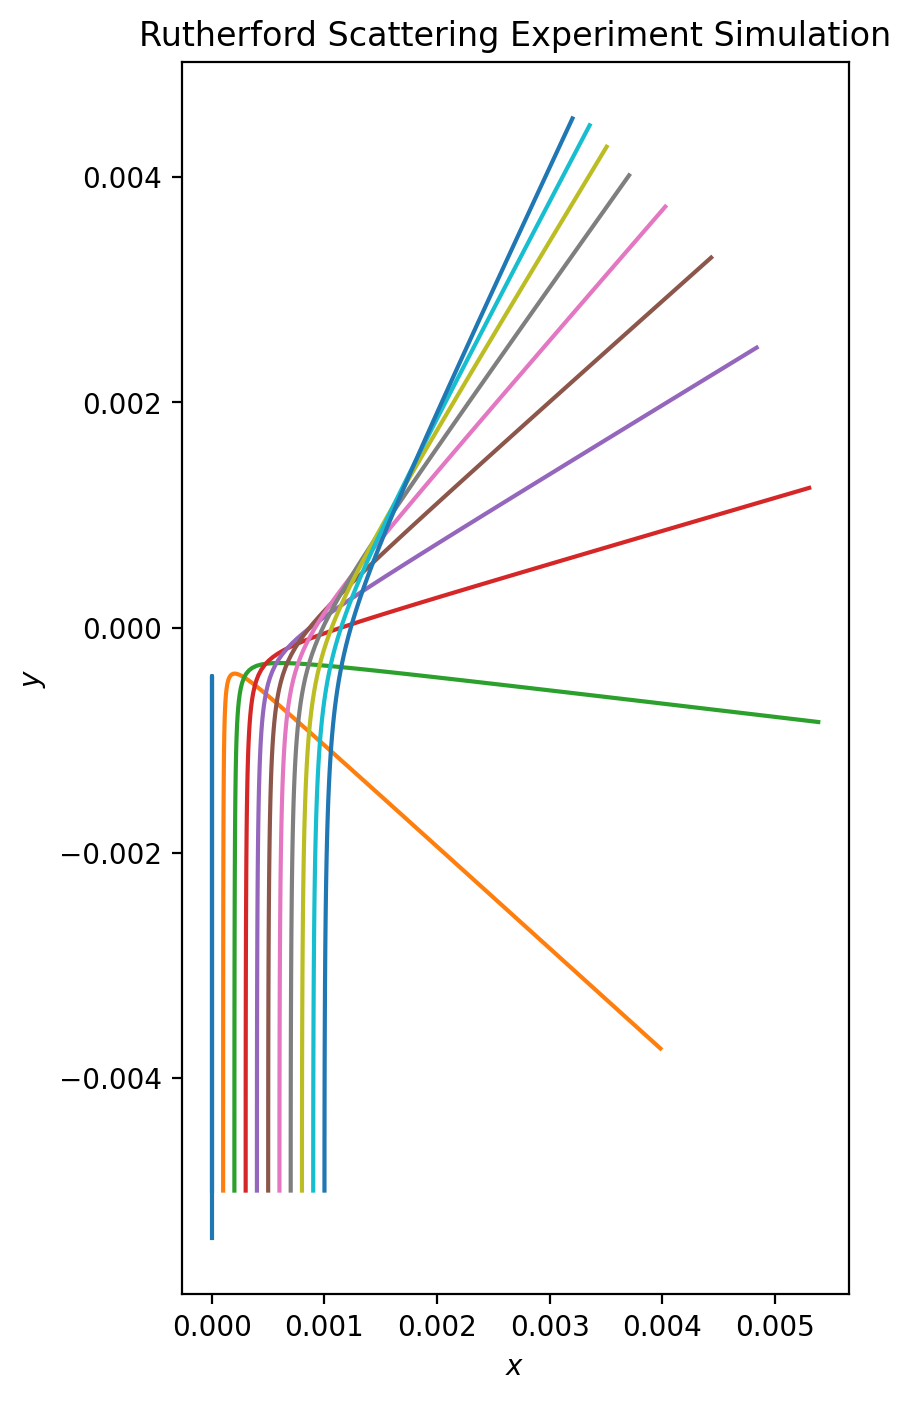

In [109]:
fig,ax = plt.subplots(figsize=(8,8),dpi=200) #Creates the figure
fig.gca().set_aspect('equal') # Set the axes to be equal
plt.title("Rutherford Scattering Experiment Simulation")
plt.xlabel("$x$")
plt.ylabel("$y$")
for i in test_params["r_initial"]: # Loops through each value of the intial positions for the alpha particle
    temporary_params = test_params.copy() #Creates a copy of the intial parameters
    temporary_params["r_Current"] = i
    Simulation(ax,i,temporary_params) # Calls the Simulation function
    
plt.show()